In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [15]:

duration_seconds = 5 * 60  # 5 minutes
interval_seconds = 30
time_capacity = np.arange(0, duration_seconds, interval_seconds)
time_traffic = np.arange(0, duration_seconds)

# Create a time series with random values between 2e7 and 9e7
random_values_capacity = np.random.uniform(2e7, 9e7, len(time_capacity))
ts_random = pd.Series(random_values_capacity, index=time_capacity)
ts_random_repeated = pd.Series(np.repeat(ts_random.values, 30), index=np.repeat(ts_random.index, 30))
ts_random_repeated.reset_index(drop=True, inplace=True)


random_values_traffic = np.random.uniform(1e7, 8e7, len(time_traffic))
ts_random_traffic = pd.Series(random_values_traffic, index=time_traffic)

for i in range (len(ts_random_traffic)):
    if ts_random_traffic[i] > ts_random_repeated[i]:
        ts_random_traffic[i] = ts_random_repeated[i] * np.random.uniform(0.5, 0.9)

np.savez('synthetic_data.npz', Capacity=ts_random_repeated, Traffic=ts_random_traffic)



print(ts_random)

0      7.018530e+07
30     2.254558e+07
60     5.869891e+07
90     4.097175e+07
120    6.432856e+07
150    7.429893e+07
180    7.224440e+07
210    8.591469e+07
240    5.818134e+07
270    8.743317e+07
dtype: float64


In [16]:
def create_syn_data_capacity_traffic(duration_seconds, interval_seconds, max_capacity, max_traffic,min_capacity, min_traffic,save=False,save_file='synthetic_data.npz'):
    time_capacity = np.arange(0, duration_seconds, interval_seconds)
    random_values_capacity = np.random.uniform(min_capacity, max_capacity, len(time_capacity))
    ts_random = pd.Series(random_values_capacity, index=time_capacity)
    ts_random_repeated = pd.Series(np.repeat(ts_random.values, 30), index=np.repeat(ts_random.index, 30))
    ts_random_repeated.reset_index(drop=True, inplace=True)

    time_traffic = np.arange(0, duration_seconds)
    random_values_traffic = np.random.uniform(min_traffic, max_traffic, len(time_traffic))
    ts_random_traffic = pd.Series(random_values_traffic, index=time_traffic)

    for i in range (len(ts_random_traffic)):
        if ts_random_traffic[i] > ts_random_repeated[i]:
            ts_random_traffic[i] = ts_random_repeated[i] * np.random.uniform(0.5, 0.9)

    if save:
        np.savez(save_file, Capacity=ts_random_repeated, Traffic=ts_random_traffic)


In [17]:
duration_seconds = 5 * 60  # 5 minutes
interval_seconds = 30
max_capacity = 9e7
max_traffic = 8e7
min_capacity = 2e7
min_traffic = 1e7
savepath='syn_data_mock/'
for i in range(10):
    create_syn_data_capacity_traffic(duration_seconds, interval_seconds, max_capacity*np.random.uniform(0.8, 1.2), max_traffic*np.random.uniform(0.8, 1.2),min_capacity*np.random.uniform(0.8, 1.2), min_traffic*np.random.uniform(0.8, 1.2),save=True,save_file=f'{savepath}synthetic_data_{i}.npz')

In [ ]:

duration_seconds = 5 * 60  # 5 minutes
interval_seconds = 30
time_capacity = np.arange(0, duration_seconds, interval_seconds)
time_traffic = np.arange(0, duration_seconds)

# Create a time series with random values between 2e7 and 9e7
random_values_capacity = np.random.uniform(2e7, 9e7, len(time_capacity))
ts_random = pd.Series(random_values_capacity, index=time_capacity)
ts_random_repeated = pd.Series(np.repeat(ts_random.values, 30), index=np.repeat(ts_random.index, 30))
ts_random_repeated.reset_index(drop=True, inplace=True)


random_values_traffic = np.random.uniform(1e7, 8e7, len(time_traffic))
ts_random_traffic = pd.Series(random_values_traffic, index=time_traffic)

for i in range (len(ts_random_traffic)):
    if ts_random_traffic[i] > ts_random_repeated[i]:
        ts_random_traffic[i] = ts_random_repeated[i] * np.random.uniform(0.5, 0.9)

np.savez('synthetic_data.npz', Capacity=ts_random_repeated, Traffic=ts_random_traffic)

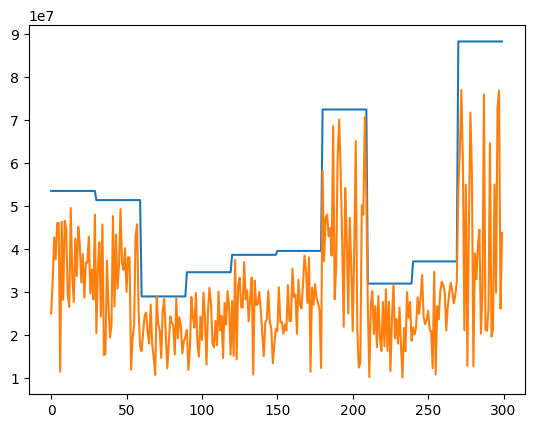

In [8]:
plt.plot(ts_random_repeated)
plt.plot(ts_random_traffic)

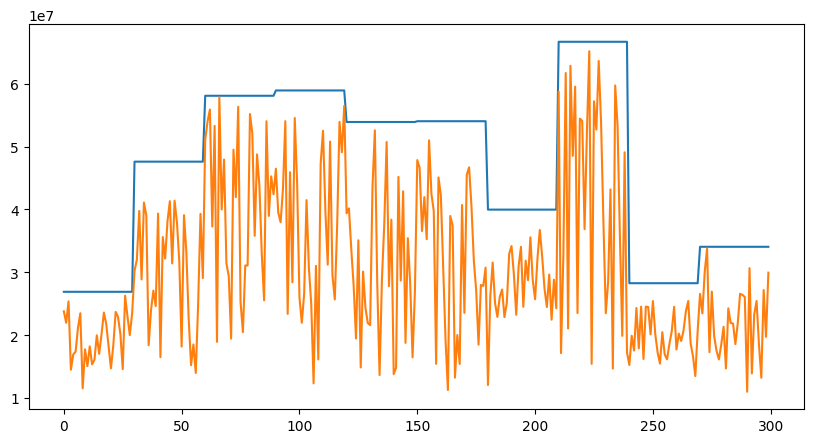

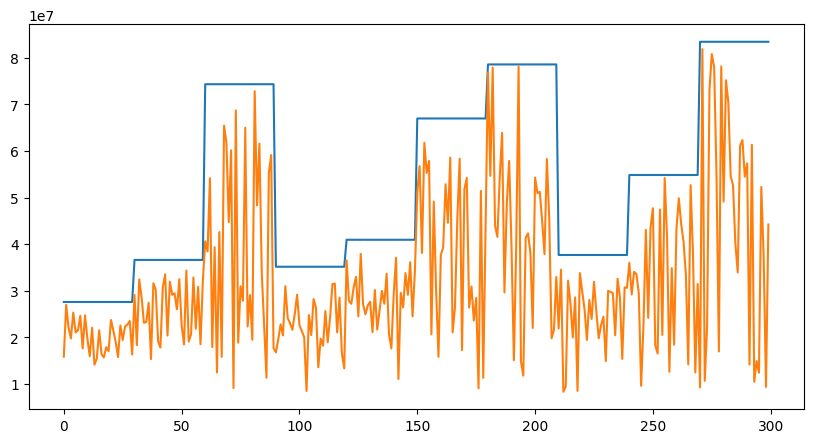

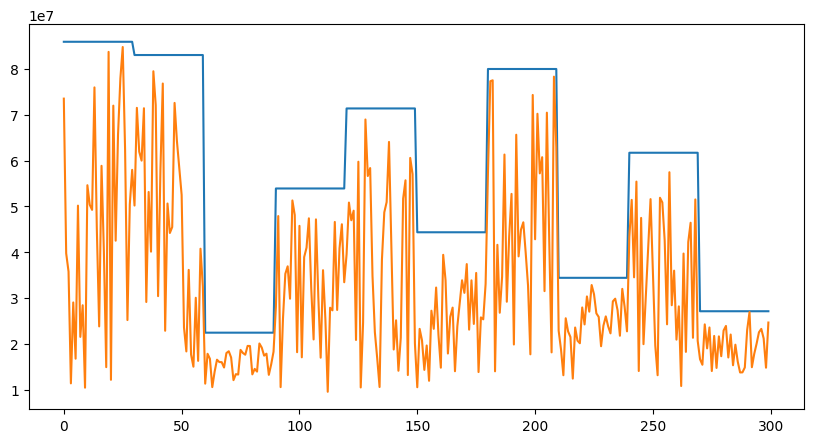

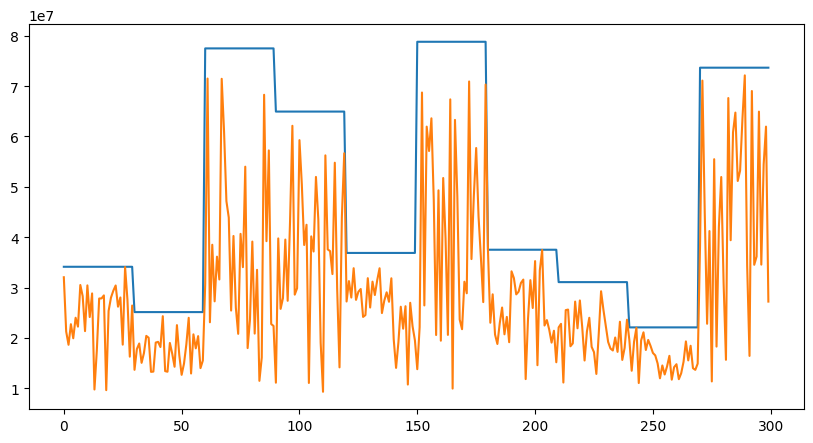

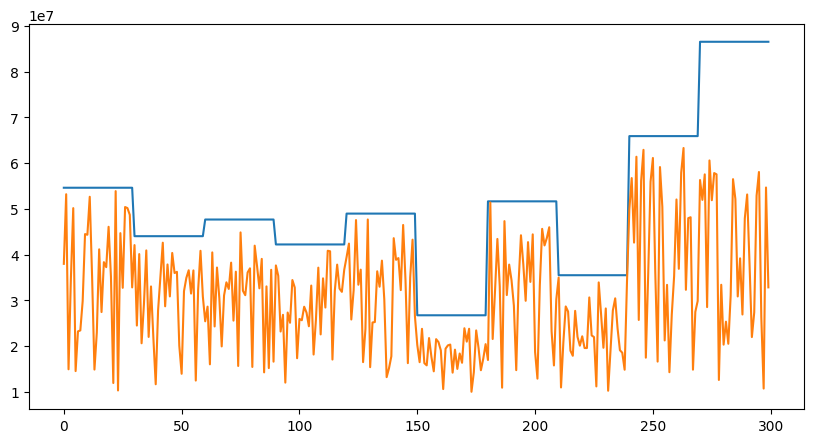

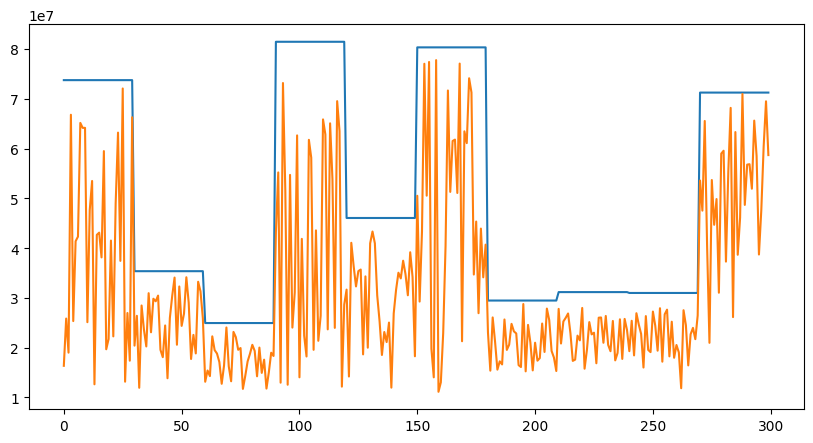

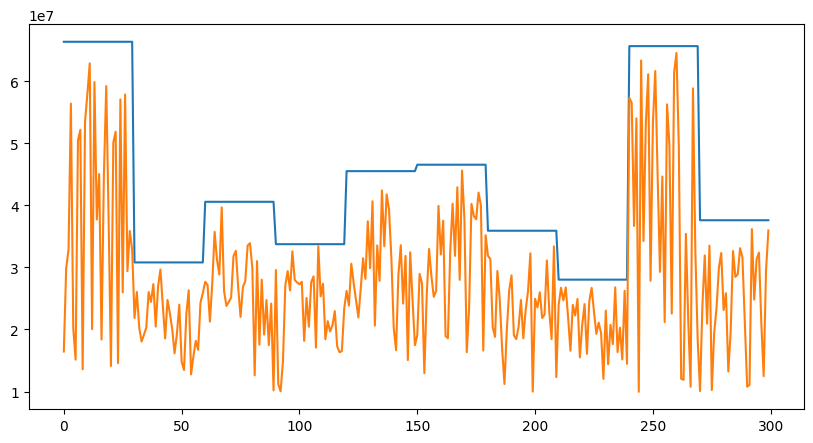

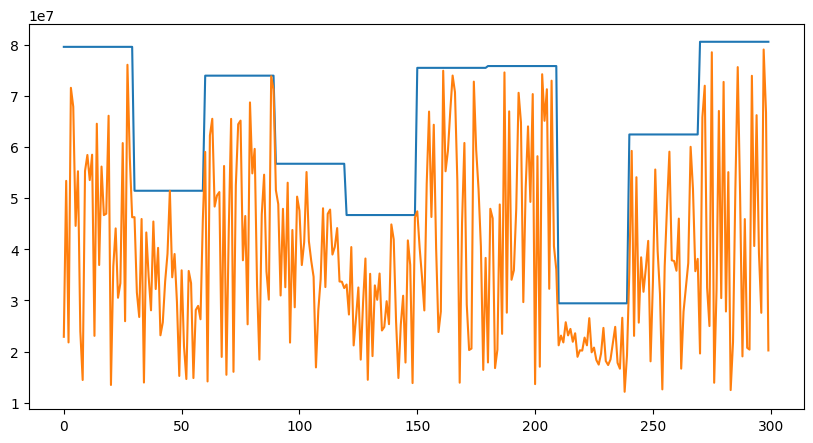

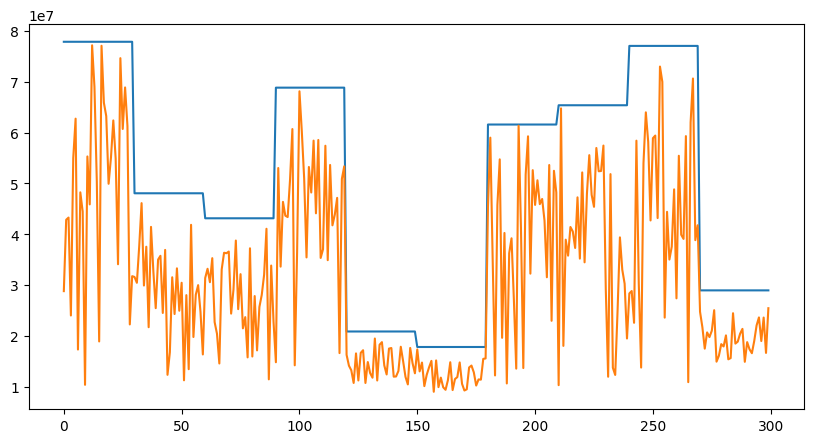

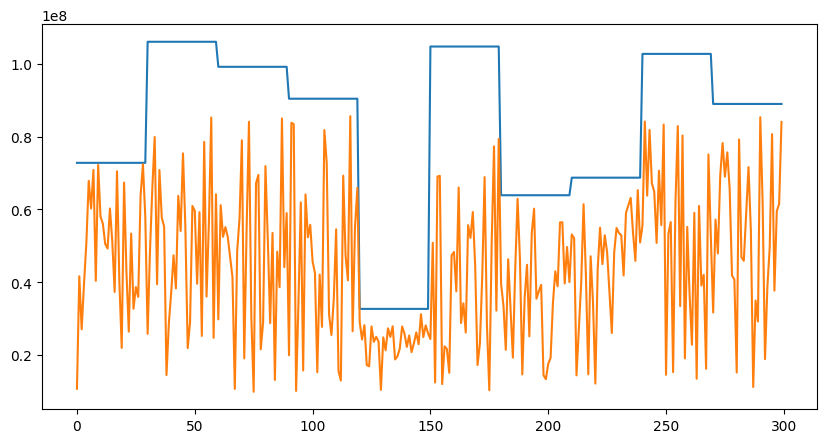

In [21]:
filedir= 'syn_data_mock/'
# filepath = 'syn_data_mock/synthetic_data_0.npz'
for i in range(10):
    plt.figure(figsize=(10, 5))
    filepath = f'{filedir}synthetic_data_{i}.npz'
    capacity, traffic = np.load(filepath, allow_pickle=True)['Capacity'], np.load(filepath, allow_pickle=True)['Traffic']
    plt.plot(capacity)
    plt.plot(traffic)